# <span style="color:#e0bda8">1. Import Packages and Libraries</span>

In [222]:
# 1. Data Manipulation
# =====================================================
import pandas as pd
import numpy as np


# 2. Dimensionality Reduction
# =====================================================
from sklearn.decomposition import PCA


# 3. Data Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns


# 4. Statistical Analysis
# =====================================================
from scipy.stats import kendalltau, spearmanr


# 5. Path Configuration
# =====================================================
import os


# 6. Utilities
# =====================================================
import warnings

warnings.filterwarnings('ignore')

# <span style="color:#e0bda8">2. Project Structure and Directory Configuration </span>   


In [223]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(PROJECT_ROOT, "01_Data")
DATA_RAW = os.path.join(DATA, "01_Raw")
DATA_PROCESSED = os.path.join(DATA, "02_Processed")
DATA_STATS = os.path.join(DATA, "03_Statistics")
DATA_INDEX = os.path.join(DATA, "04_Index_Final")
FINAL_DATA = os.path.join(DATA, "05_Final_Data")

EDA = os.path.join(PROJECT_ROOT, "03_EDA")

CLUSTER_PCA = os.path.join(PROJECT_ROOT, "04_Clustering_PCA")
CLUSTER_PCA_EXCEL = os.path.join(CLUSTER_PCA, "01_Excel")
CLUSTER_PCA_FIG = os.path.join(CLUSTER_PCA, "02_Figures")

METHOD = os.path.join(PROJECT_ROOT, "05_Method_Comparison")
METHOD_EXCEL = os.path.join(METHOD, "01_Excel")
METHOD_FIG = os.path.join(METHOD, "02_Figures")

ML_RESULTS = os.path.join(PROJECT_ROOT, "06_ML_Results")
ML_METRICS = os.path.join(ML_RESULTS, "01_Metrics")
ML_PRED = os.path.join(ML_RESULTS, "02_Predictions")
ML_MODELS = os.path.join(ML_RESULTS, "03_Models")
ML_SHAP = os.path.join(ML_RESULTS, "04_SHAP")
ML_SHAP_EXCEL = os.path.join(ML_SHAP, "01_Excel")
ML_SHAP_FIG = os.path.join(ML_SHAP, "02_Figures")

FINAL_SCORES = os.path.join(PROJECT_ROOT, "07_Final_ESG_Scores")
FINAL_SCORES_EXCEL = os.path.join(FINAL_SCORES, "01_Excel")
FINAL_SCORES_FIG = os.path.join(FINAL_SCORES, "02_Figures")

# <span style="color:#e0bda8">3. Reading the Data</span>

In [224]:
df_env_score = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_env_mm.csv')) 
df_env_score = df_env_score.set_index(['Economy', 'Year'])

df_soc_score = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_soc_mm.csv'))
df_soc_score = df_soc_score.set_index(['Economy', 'Year'])

df_gov_score = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_gov_mm.csv'))
df_gov_score = df_gov_score.set_index(['Economy', 'Year'])

# <span style="color:#e0bda8">4. Index Scores Construction </span>

## <span style="color:#e0bda8">4.1. Equal Weights </span>

In [225]:
def equal_weighted_index(df):
    """
    Computes an equal-weight composite index and rescales it to a 0–100 range.

    Each variable contributes equally to the final score.
    """

    # Number of variables
    n_vars = df.shape[1]

    # Assign equal weights (sum to 1)
    weights = np.ones(n_vars) / n_vars

    # Compute weighted score (linear aggregation)
    score = df.values @ weights

    # Compute theoretical maximum score based on column-wise maxima
    col_max = df.max(axis=0).values  
    score_max = np.sum(weights * col_max)

    # Compute theoretical minimum score based on column-wise minima
    col_min = df.min(axis=0).values
    score_min = np.sum(weights * col_min)

    # Rescale scores to a 0–100 range
    score_0_100 = 100 * (score - score_min) / (score_max - score_min)
    
    # Return as DataFrame preserving original index
    score_df = pd.DataFrame(score_0_100, index=df.index, columns=['Score'])
    
    return score_df

In [226]:
E_score_equal = equal_weighted_index(df_env_score)
S_score_equal = equal_weighted_index(df_soc_score)
G_score_equal = equal_weighted_index(df_gov_score)

## <span style="color:#e0bda8">4.2. PCA Explained Variance Weights </span>

In [227]:
def cumulative_variance_plot(env_df, soc_df, gov_df, png=True):
    """
    Computes and visualizes cumulative explained variance from PCA
    for Environmental, Social, and Governance datasets.

    The function also prints the individual and cumulative variance
    explained by each principal component.
    """

    # --- Fit PCA separately for each ESG pillar ---
    pca = PCA(n_components=8, random_state=42)

    pca.fit(env_df)
    env_cum = np.cumsum(pca.explained_variance_ratio_) * 100

    pca.fit(soc_df)
    soc_cum = np.cumsum(pca.explained_variance_ratio_) * 100

    pca.fit(gov_df)
    gov_cum = np.cumsum(pca.explained_variance_ratio_) * 100

    pcs = np.arange(1, 9)

    # --- Plot cumulative variance ---
    plt.figure(figsize=(10, 6))

    plt.plot(pcs, env_cum, marker='o', label='Environmental Pillar', color='tab:blue')
    plt.plot(pcs, soc_cum, marker='s', label='Social Pillar', color='tab:orange')
    plt.plot(pcs, gov_cum, marker='^', label='Governance Pillar', color='tab:green')

    # Reference threshold (explained variance target)
    plt.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% Variance Threshold')

    # Highlight selected number of components per pillar
    plt.scatter(
        [8, 5, 3],
        [env_cum[7], soc_cum[4], gov_cum[2]],
        color=['blue', 'orange', 'green'],
        s=100,
        zorder=5
    )

    plt.text(8, env_cum[7] + 2, '8 PCs', color='blue', fontsize=10)
    plt.text(5, soc_cum[4] + 2, '5 PCs', color='orange', fontsize=10)
    plt.text(3, gov_cum[2] + 2, '3 PCs', color='green', fontsize=10)

    # --- Axis formatting ---
    plt.xticks(pcs)
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Cumulative Explained Variance by Number of Principal Components")

    plt.legend()
    plt.grid(False)
    plt.tight_layout()

    # --- Save figure if required ---
    if png:
        plt.savefig(
            os.path.join(CLUSTER_PCA_FIG, 'ESG_pca_cumulative_variance.png'),
            dpi=300
        )

    # --- Print variance summary table ---
    print("=== Variance Explained ===")
    print(f"{'PCs':<5} {'Env (ind)':>10} {'Env (cum)':>10} {'Soc (ind)':>10} {'Soc (cum)':>10} {'Gov (ind)':>10} {'Gov (cum)':>10}")
    print("-" * 65)

    pca_env = PCA(n_components=8, random_state=42).fit(env_df)
    pca_soc = PCA(n_components=8, random_state=42).fit(soc_df)
    pca_gov = PCA(n_components=8, random_state=42).fit(gov_df)

    for i in range(8):
        print(
            f"{i+1:<5} "
            f"{pca_env.explained_variance_ratio_[i]*100:>10.2f} "
            f"{env_cum[i]:>10.2f} "
            f"{pca_soc.explained_variance_ratio_[i]*100:>10.2f} "
            f"{soc_cum[i]:>10.2f} "
            f"{pca_gov.explained_variance_ratio_[i]*100:>10.2f} "
            f"{gov_cum[i]:>10.2f}"
        )

    plt.show()

=== Variance Explained ===
PCs    Env (ind)  Env (cum)  Soc (ind)  Soc (cum)  Gov (ind)  Gov (cum)
-----------------------------------------------------------------
1          26.01      26.01      48.18      48.18      65.62      65.62
2          12.92      38.93      13.11      61.29      11.89      77.51
3           9.89      48.82       9.37      70.66       6.92      84.43
4           8.39      57.21       5.58      76.24       5.49      89.92
5           7.26      64.47       4.13      80.37       3.39      93.30
6           5.94      70.41       3.50      83.87       2.36      95.67
7           5.25      75.66       3.30      87.17       1.86      97.52
8           4.75      80.41       2.59      89.76       0.99      98.51


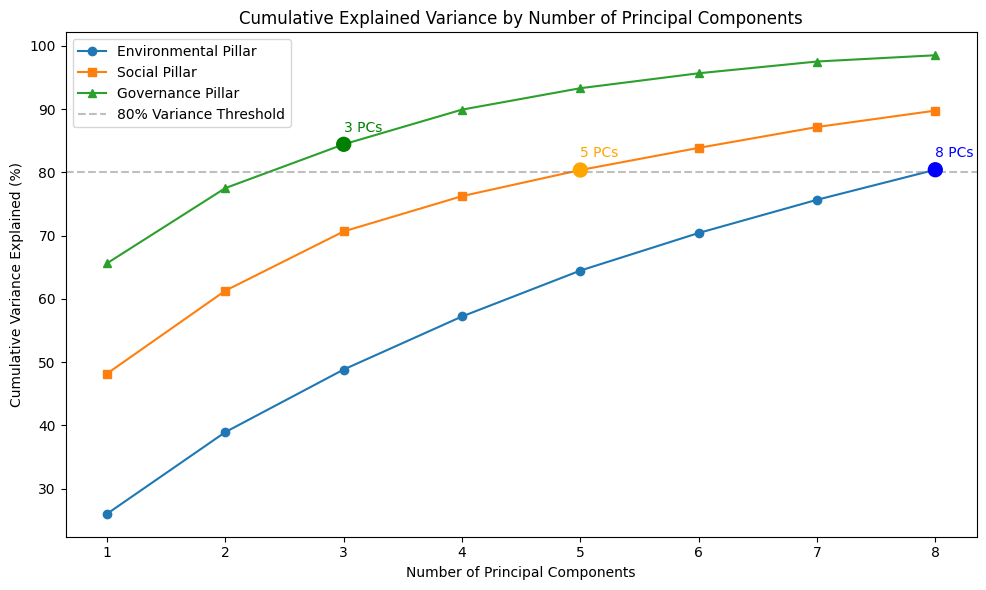

In [228]:
cumulative_variance_plot(df_env_score, df_soc_score, df_gov_score, png=False)

In [229]:
def pca_variance_weighted_index(df, n_components=None):
    """
    Computes a PCA-based composite index where variable weights are derived 
    from absolute loadings weighted by explained variance.

    The final index is rescaled to a 0–100 range.
    """

    # 1. Fit PCA on the input data
    pca = PCA(n_components=n_components)
    pca.fit(df)

    # 2. Extract absolute loadings (variables × components)
    loadings = np.abs(pca.components_.T)

    # 3. Get explained variance ratio of each component
    explained_var = pca.explained_variance_ratio_

    # 4. Compute raw weights as loadings weighted by explained variance
    raw_weights = loadings @ explained_var

    # 5. Normalize weights to sum to 1
    weights = raw_weights / raw_weights.sum()

    # 6. Compute weighted score (linear aggregation)
    score = df.values @ weights

    # 7. Compute theoretical maximum score based on column-wise maxima
    col_max = df.max(axis=0).values
    score_max = np.sum(weights * col_max)

    # 8. Compute theoretical minimum score based on column-wise minima
    col_min = df.min(axis=0).values
    score_min = np.sum(weights * col_min)

    # 9. Rescale scores to a 0–100 range
    score_0_100 = 100 * (score - score_min) / (score_max - score_min)

    # 10. Return scores as DataFrame preserving index
    score_df = pd.DataFrame(score_0_100, index=df.index, columns=['Score'])

    return score_df

In [230]:
E_score_pca = pca_variance_weighted_index(df_env_score, n_components=8) 
S_score_pca = pca_variance_weighted_index(df_soc_score, n_components=5) 
G_score_pca = pca_variance_weighted_index(df_gov_score, n_components=3) 

## <span style="color:#e0bda8">4.3. Variance-Based Weights </span>

In [231]:
def variance_weighted_index(df):
    """
    Computes a composite index where variable weights are proportional 
    to their variance.

    Variables with higher variability receive greater importance.
    The final index is rescaled to a 0–100 range.
    """
    
    # 1. Compute variance of each variable
    variances = df.var(axis=0)
    
    # 2. Normalize variances to obtain weights (sum to 1)
    weights = variances / variances.sum()
    
    # 3. Compute weighted score (linear aggregation)
    score = df.values @ weights
    
    # 4. Compute theoretical maximum score based on column-wise maxima
    col_max = df.max(axis=0).values
    score_max = np.sum(weights * col_max)

    # 5. Compute theoretical minimum score based on column-wise minima
    col_min = df.min(axis=0).values
    score_min = np.sum(weights * col_min)

    # 6. Rescale scores to a 0–100 range
    score_0_100 = 100 * (score - score_min) / (score_max - score_min)
    
    # 7. Return scores as DataFrame preserving index
    score_df = pd.DataFrame(score_0_100, index=df.index, columns=['Score'])
    
    return score_df

In [232]:
E_score_variance = variance_weighted_index(df_env_score)
S_score_variance = variance_weighted_index(df_soc_score)
G_score_variance = variance_weighted_index(df_gov_score)

## <span style="color:#e0bda8">4.4. Entropy-Based Weights </span>

In [233]:
def entropy_weighted_index(df, epsilon=1e-12):
    """
    Computes an entropy-weighted composite index.

    Variables with lower entropy (higher information content) receive higher weights.
    The final index is rescaled to a 0–100 range.
    """

    # 1. Normalize each column into a probability distribution
    p = df.div(df.sum(axis=0) + epsilon, axis=1)

    # 2. Compute entropy for each variable
    k = 1 / np.log(df.shape[0])  # normalization constant
    entropy = -k * (p * np.log(p + epsilon)).sum(axis=0)

    # 3. Convert entropy into information content
    info = 1 - entropy

    # 4. Normalize information to obtain weights
    weights = info / info.sum()

    # 5. Compute weighted score (linear aggregation)
    score = df.values @ weights.values

    # 6. Compute theoretical maximum score based on column-wise maxima
    col_max = df.max(axis=0).values
    score_max = np.sum(weights * col_max)

    # 7. Compute theoretical minimum score based on column-wise minima
    col_min = df.min(axis=0).values
    score_min = np.sum(weights * col_min)

    # 8. Rescale scores to a 0–100 range
    score_0_100 = 100 * (score - score_min) / (score_max - score_min)

    # 9. Return scores as DataFrame preserving index
    score_df = pd.DataFrame(score_0_100, index=df.index, columns=['Score'])

    return score_df

In [234]:
E_score_entropy = entropy_weighted_index(df_env_score)
S_score_entropy = entropy_weighted_index(df_soc_score)
G_score_entropy = entropy_weighted_index(df_gov_score)

## <span style="color:#e0bda8">4.5. Score Aggregation into Dataframe </span>

In [235]:
# For Environmental pillar
original_combined_env = pd.DataFrame({
    'Equal': E_score_equal['Score'],
    'Variance': E_score_variance['Score'],
    'Entropy': E_score_entropy['Score'],
    'PCA': E_score_pca['Score']
})

# For Social pillar
original_combined_soc = pd.DataFrame({
    'Equal': S_score_equal['Score'],
    'Variance': S_score_variance['Score'],
    'Entropy': S_score_entropy['Score'],
    'PCA': S_score_pca['Score']
})

# For Governance pillar
original_combined_gov = pd.DataFrame({
    'Equal': G_score_equal['Score'],
    'Variance': G_score_variance['Score'],
    'Entropy': G_score_entropy['Score'],
    'PCA': G_score_pca['Score']
})

original_combined = {
    'Environmental': original_combined_env,
    'Social': original_combined_soc,
    'Governance': original_combined_gov
}

# <span style="color:#e0bda8">5. Comparison of Score Weighting Methods </span>

## <span style="color:#e0bda8">5.1. Evaluation of Score Methods</span>

In [236]:
class ESGScoreEvaluator:
    """
    Comprehensive evaluator for Sovereign ESG score models (37 European Countries, 2012-2020).
    Evaluates: Consistency, Robustness, Stability, Interpretability, and Sensitivity to Noise.
    """

    def __init__(self, E_combined, S_combined, G_combined, E_orig, S_orig, G_orig):

        self.E_combined = E_combined
        self.S_combined = S_combined
        self.G_combined = G_combined

        self.E_orig = E_orig
        self.S_orig = S_orig
        self.G_orig = G_orig

        self.pillars = {
            'Environmental': {
                'data': E_orig,      
                'scores': E_combined  
            },
            'Social': {
                'data': S_orig, 
                'scores': S_combined
            },
            'Governance': {
                'data': G_orig, 
                'scores': G_combined
            }
        }

        self.methods = ['Equal', 'PCA', 'Entropy', 'Variance']
        self.N_countries = next(iter(self.pillars.values()))['scores'].shape[0]
        self.results = {}

    def evaluate_internal_consistency(self):
        """CRITERION 1: INTERNAL CONSISTENCY"""
        print("=" * 80)
        print("CRITERION 1: INTERNAL CONSISTENCY")
        print("=" * 80)
        consistency_results = {}

        for pillar_name, pillar_data in self.pillars.items():
            df_score = pillar_data['scores']
            corr_matrix = df_score[self.methods].corr(method='pearson')
            mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
            avg_correlation = corr_matrix.where(mask).stack().mean()

            cv_scores = (df_score[self.methods].std(axis=1) / df_score[self.methods].mean(axis=1)).mean()

            consistency_results[pillar_name] = {
                'correlation_matrix': corr_matrix,
                'avg_correlation': avg_correlation,
                'mean_cv': cv_scores
            }
        
        self.results['internal_consistency'] = consistency_results
        return consistency_results

    def evaluate_robustness_to_extremes(self):
        """CRITERION 2: ROBUSTNESS TO EXTREMES"""
        print("\n" + "=" * 80)
        print("CRITERION 2: ROBUSTNESS TO EXTREMES")
        print("=" * 80)
        robustness_results = {}

        for pillar_name, pillar_data in self.pillars.items():
            df_score = pillar_data['scores']
            method_robustness = {}
            for method in self.methods:
                scores = df_score[method].dropna()
                Q1, Q3 = scores.quantile(0.25), scores.quantile(0.75)
                IQR = Q3 - Q1
                outliers = scores[(scores < Q1 - 1.5 * IQR) | (scores > Q3 + 1.5 * IQR)]
                outlier_pct = len(outliers) / len(scores) * 100
                mad = np.median(np.abs(scores - scores.median()))
                robust_cv = mad / scores.median() if scores.median() != 0 else np.nan

                method_robustness[method] = {
                    'outlier_percentage': outlier_pct,
                    'skewness': scores.skew(),
                    'kurtosis': scores.kurtosis(),
                    'range': scores.max() - scores.min(),
                    'iqr': IQR,
                    'robust_cv': robust_cv
                }
            robustness_results[pillar_name] = method_robustness
            
        self.results['robustness'] = robustness_results
        return robustness_results

    def evaluate_ranking_stability(self): 
        """CRITERION 3: RANKING STABILITY"""
        print("\n" + "=" * 80)
        print("CRITERION 3: RANKING STABILITY")
        print("=" * 80)
        stability_results = {}

        for pillar_name, pillar_data in self.pillars.items():
            df_score = pillar_data['scores']
            rankings = df_score[self.methods].rank(ascending=False, method='average')
            rank_corr_matrix = rankings.corr(method='spearman')
            
            kendall_df = pd.DataFrame(index=self.methods, columns=self.methods, dtype=float)
            kendall_vals = []
            for i, m1 in enumerate(self.methods):
                for m2 in self.methods[i+1:]:
                    tau, _ = kendalltau(rankings[m1], rankings[m2])
                    kendall_vals.append(tau)
                    kendall_df.loc[m1, m2] = tau
                    kendall_df.loc[m2, m1] = tau 
            np.fill_diagonal(kendall_df.values, 1)

            displacement_df = pd.DataFrame(index=self.methods, columns=self.methods, dtype=float)
            for m1 in self.methods:
                for m2 in self.methods:
                    displacement_df.loc[m1, m2] = np.abs(rankings[m1] - rankings[m2]).mean()
            rank_displacements = displacement_df.where(~np.eye(len(displacement_df),dtype=bool)).mean(axis=1).to_dict()

            top10_df = pd.DataFrame(index=self.methods, columns=self.methods, dtype=float)
            for m1 in self.methods:
                top10_m1 = set(rankings[m1].nsmallest(10).index)
                for m2 in self.methods:
                    top10_m2 = set(rankings[m2].nsmallest(10).index)
                    overlap = len(top10_m1.intersection(top10_m2)) / 10 * 100
                    top10_df.loc[m1, m2] = overlap
            top10_overlaps = top10_df.where(~np.eye(len(top10_df),dtype=bool)).mean(axis=1).to_dict()

            stability_results[pillar_name] = {
                'rank_correlation_matrix': rank_corr_matrix,
                'kendall_pairwise': kendall_df,   
                'rank_displacements': rank_displacements,
                'rank_displacements_pairwise': displacement_df,
                'top10_overlaps': top10_overlaps,
                'top10_overlaps_pairwise': top10_df
            }
            
        self.results['stability'] = stability_results
        return stability_results

    def evaluate_interpretability(self):
        
        """CRITERION 4: INTERPRETABILITY"""
        print("\n" + "=" * 80)
        print("CRITERION 4: INTERPRETABILITY")
        print("=" * 80)
        interpretability_results = {}

        for pillar_name, pillar_data in self.pillars.items():
            df_score = pillar_data['scores']
            method_interpret = {}
            for method in self.methods: 
                scores = df_score[method].dropna()
                bins = pd.cut(scores, bins=10, labels=False)
                counts = pd.Series(bins).value_counts(normalize=True)
                entropy = -np.sum(counts * np.log(counts + 1e-10))
                norm_entropy = entropy / np.log(10) 
                sorted_s = np.sort(scores)
                n = len(sorted_s)
                gini = (2 * np.sum(np.arange(1, n+1) * sorted_s)) / (n * np.sum(sorted_s)) - (n + 1) / n

                method_interpret[method] = {
                    'mean': scores.mean(), 'median': scores.median(), 'std': scores.std(),
                    'range_utilization': (scores.max() - scores.min()),
                    'normalized_entropy': norm_entropy, 
                    'gini_coefficient': gini
                }
            interpretability_results[pillar_name] = method_interpret

        self.results['interpretability'] = interpretability_results
        return interpretability_results

    def evaluate_sensitivity_to_noise(self, n_iterations=100, noise_level=0.01, random_state=42):
        """
        SENSITIVITY TEST: Adds noise to the indicators and RECALCULATES the models.
        Tests how sensitive the weighting algorithms (PCA, Entropy, etc.) are.
        """

        print("\n" + "=" * 80)
        print(f"CRITERION 5: SENSITIVITY TEST ({n_iterations} iterations on the data)")
        print("=" * 80)

        sensitivity_results = {}
        PCA_COMPONENTS = {
        'Environmental': 8,
        'Social': 5,
        'Governance': 3
        }

        rng = np.random.default_rng(random_state)

        for pillar_name, pillar_data in self.pillars.items():
            data = pillar_data['data'].copy()
            df_score = pillar_data['scores'] 
            rank_orig = df_score[self.methods].rank(ascending=False, method='average')
            
            pillar_method_results = {m: {'corrs': [], 'disps': [], 'tops': [], 'ranks': []} for m in self.methods}

            for i in range(n_iterations):
                # 1. Adds noise to the original indicators
                noise = rng.normal(0, noise_level, data.shape)
                df_noisy = data * (1 + noise)
                
                # 2. Recalculates scores for each method using the noisy data
                for method in self.methods:
                    if method == 'Equal':
                        noisy_score = equal_weighted_index(df_noisy)
                
                    elif method == 'Variance':
                        noisy_score = variance_weighted_index(df_noisy)
                        
                    elif method == 'Entropy':
                        noisy_score = entropy_weighted_index(df_noisy)
                        
                    elif method == 'PCA':
                        noisy_score = pca_variance_weighted_index(df_noisy, n_components=PCA_COMPONENTS[pillar_name])
                    
                    
                    # 3. Generates a new ranking and compares with the original method ranking
                    rank_noise = noisy_score['Score'].rank(ascending=False, method='average')
                    rank_noise.index = rank_orig.index
                    
                    corr, _ = spearmanr(rank_orig[method], rank_noise)
                    disp = np.abs(rank_orig[method] - rank_noise).mean()
                    
                    top10_orig = set(rank_orig[method].nsmallest(10).index)
                    top10_noise = set(rank_noise.nsmallest(10).index)
                    overlap = len(top10_orig.intersection(top10_noise)) / 10 * 100

                    pillar_method_results[method]['corrs'].append(corr)
                    pillar_method_results[method]['disps'].append(disp)
                    pillar_method_results[method]['tops'].append(overlap)
                    pillar_method_results[method]['ranks'].append(rank_noise)

            # 4. Consolidate results
            sensitivity_results[pillar_name] = {
                m: {
                    'mean_spearman': np.mean(pillar_method_results[m]['corrs']),
                    'std_spearman': np.std(pillar_method_results[m]['corrs']),
                    'mean_rank_displacement': np.mean(pillar_method_results[m]['disps']),
                    'mean_top10_stability': np.mean(pillar_method_results[m]['tops']),
                    'rank_std_error': pd.concat(pillar_method_results[m]['ranks'], axis=1).std(axis=1).mean()
                } for m in self.methods
            }

        self.results['sensitivity'] = sensitivity_results
        return sensitivity_results

    def generate_comparative_summary(self):
        """
        AGGREGATE PERFORMANCE SCORE - REVISED TWO-STEP METHODOLOGY
        Separates 'Agreement/Consensus' from 'Technical Quality/Performance'.
        The final recommendation is driven by Technical Quality, not by consensus.
        """
        print("\n" + "=" * 80)
        print("GENERATING REVISED COMPARATIVE SUMMARY (2-STEP FRAMEWORK)")
        print("=" * 80)
        summary = {}

        for p_name in self.pillars.keys():
            method_analysis = {}
            
            for m in self.methods:
                # --- STEP 1: AGREEMENT INDEX (Consensus with other methods) ---
                # Measures how "typical" or aligned this method is with the group.
                # Low agreement doesn't mean the method is bad; it means it is "unique".
                consistency = self.results['internal_consistency'][p_name]['avg_correlation']

                # --- STABILITY SCORE (Rank Displacement + Top10 Overlap) ---
                # Number of countries
                N_countries = self.N_countries  

                # --- Rank Displacement Normalization ---
                rd_dict = self.results['stability'][p_name]['rank_displacements']
                t10_dict = self.results['stability'][p_name]['top10_overlaps']

                # Rank Displacement Normalization (values between 0 and N/2):
                rd_norm = 1 - np.clip(rd_dict[m] / (N_countries / 2), 0, 1)

                # Top10 Overlap Normalization
            
                # Natural Percentage, 0–100 → 0–1
                t10_norm = t10_dict[m] / 100

                # Stability Score final 
                stability_score = (rd_norm + t10_norm) / 2

                # Agreement Index 
                agreement_index = (consistency + stability_score) / 2

                # --- STEP 2: TECHNICAL QUALITY INDEX (Intrinsic Performance) ---
                
                # A. Sensitivity (Stress Test) - Weight: 50%
                # Measures resilience to noise. A sovereign score must be stable year-over-year.

                sens = self.results['sensitivity'][p_name][m]
                N_countries = self.pillars[p_name]['scores'].shape[0]

                # Components
                spearman_component = sens['mean_spearman'] 
                top10_component = sens['mean_top10_stability'] / 100  
                disp_component = 1 - np.clip(sens['mean_rank_displacement'] / (N_countries / 2), 0, 1)  

                # Average of the 3 components
                sensitivity_score = (spearman_component + top10_component + disp_component) / 3
                
                # B. Robustness (Extremes) - Weight: 25%.
                rob = self.results['robustness'][p_name][m]

                outlier_score = 1 - rob['outlier_percentage'] / 100
                skew_score = 1 - min(abs(rob['skewness']) / 3, 1)

                # Robustness Score 
                robustness_score = (outlier_score + skew_score) / 2 
                
                # C. Interpretability (Distribution) - Weight: 25%
                # Measures if the scores use the full scale (Entropy) and avoid extreme inequality (Gini).
                interp = self.results['interpretability'][p_name][m]

                # Normalizes gini around 0.4
                gini_score = 1 - np.clip(abs(interp['gini_coefficient'] - 0.4) / 0.6, 0, 1)  

                # Uses normalized entropy 
                entropy_score = interp['normalized_entropy']

                # Range Utilization 
                range_score = interp['range_utilization'] / 100

                # Final interpretability score: weighted average
                interpretability_score = (0.4*entropy_score + 0.4*gini_score + 0.2*range_score)
                
                # Weighted Final Quality Score
                quality_index = (0.50 * sensitivity_score) + (0.25 * robustness_score) + (0.25 * interpretability_score)

                method_analysis[m] = {
                    'Agreement_Index': agreement_index,
                    'Technical_Quality_Index': quality_index,
                
                    # Store raw components for the Radar Chart
                    'radar_values': [consistency, robustness_score, stability_score, interpretability_score, sensitivity_score]
                }
            
            summary[p_name] = {
                'metrics': method_analysis,
                'summary_indices': {m: {
                    'Agreement_Index': v['Agreement_Index'],
                    'Technical_Quality_Index': v['Technical_Quality_Index']
                } for m, v in method_analysis.items()}
            }
            
        self.results['summary'] = summary
        return summary

    def create_visualizations(self):
        """GENERATE VISUALIZATIONS"""
        print("\n" + "=" * 80)
        print("GENERATING VISUALIZATIONS")
        print("=" * 80)

        # 1. Consistency Heatmaps
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        vmin = 0 
        vmax = 1.00   

        for idx, (pillar, data) in enumerate(self.results['internal_consistency'].items()):
            sns.heatmap(data['correlation_matrix'], annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[idx], vmin=vmin, vmax=vmax)
            axes[idx].set_title(f'Pairwise Pearson Score Correlation — {pillar} Pillar', fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(METHOD_FIG, "esg_internal_consistency.png"), dpi=300)

       
        # 2. Stability Heatmaps
        stability_metrics = [
            ('rank_correlation_matrix', 'Pairwise Spearman Rank Correlation', 'esg_spearman_stability.png', 'RdYlGn'),
            ('kendall_pairwise', 'Pairwise Kendall\'s Tau Rank Correlation', 'esg_kendall_stability.png', 'RdYlGn'),
            ('top10_overlaps_pairwise', 'Pairwise Top-10 Rank Overlap', 'esg_top10_overlap.png', 'RdYlGn'),
            ('rank_displacements_pairwise', 'Pairwise Mean Rank Displacement', 'esg_rank_displacement.png', 'RdYlGn_r')
        ]
        
        all_disp = []

        for pillar in self.results['stability']:
            mat = self.results['stability'][pillar]['rank_displacements_pairwise'].values
            all_disp.extend(mat.flatten())

        N_countries = self.N_countries
        scale_settings = {
            'rank_correlation_matrix': {'vmin': 0, 'vmax': 1.0},
            'kendall_pairwise': {'vmin': 0, 'vmax': 1.0},
            'top10_overlaps_pairwise': {'vmin': 0, 'vmax': 100},
            'rank_displacements_pairwise': {'vmin': 0, 'vmax': N_countries/2}
        }


        for metric_key, title_suffix, file_name, cmap_name in stability_metrics:
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            for idx, pillar in enumerate(self.pillars.keys()):
                data_matrix = self.results['stability'][pillar][metric_key]

                settings = scale_settings[metric_key]
                
                fmt_str = '.3f' 
                
                sns.heatmap(data_matrix, 
                            annot=True, 
                            fmt=fmt_str, 
                            cmap=cmap_name, 
                            vmin=settings['vmin'],
                            vmax=settings['vmax'],
                            ax=axes[idx])
                
                axes[idx].set_title(f'{title_suffix} — {pillar} Pillar', fontweight='bold')
            
            plt.tight_layout()
            plt.savefig(os.path.join(METHOD_FIG, file_name), dpi=300)
            print(f"Saved: {file_name}")


        # 3. Histograms
        fig, axes = plt.subplots(3, 4, figsize=(20, 15))
        for row, (pillar, pilar_data) in enumerate(self.pillars.items()):
            df = pilar_data['scores']  
            for col, method in enumerate(self.methods):
                ax = axes[row, col]
                scores = df[method].dropna()
                ax.hist(scores, bins=30, alpha=0.7, color='lightpink', edgecolor='black')
                ax.axvline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.1f}')
                ax.axvline(scores.median(), color='blue', linestyle='--', label=f'Median: {scores.median():.1f}')
                ax.set_title(f'Score Distribution under {method} Weighting — {pillar} Pillar', fontweight='bold')
                ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(METHOD_FIG, "esg_score_distributions.png"), dpi=300)

        # 4. Sensitivity Bar Plots

        for pillar in self.pillars.keys():
            fig, axes = plt.subplots(1, 3, figsize=(20, 6))
            sens_df = pd.DataFrame(self.results['sensitivity'][pillar]).T

            metrics_to_plot = [
                ('mean_spearman', 'Rank Correlation Under Perturbation (Spearman)', 'skyblue'),
                ('mean_top10_stability', 'Top-10 Rank Overlap Under Perturbation (%)', 'lightgreen'),
                ('mean_rank_displacement', 'Mean Rank Displacement Under Perturbation', 'salmon')
            ]

            for i, (col, title, color) in enumerate(metrics_to_plot):
                sns.barplot(x=sens_df.index, y=sens_df[col], ax=axes[i], color=color, edgecolor='black')
                axes[i].set_title(title, fontweight='bold', fontsize=12)
                axes[i].set_xlabel('Method')
                axes[i].set_ylabel('Value')

                for p in axes[i].patches:
                    axes[i].annotate(f'{p.get_height():.2f}', 
                                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                                   ha='center', va='center', xytext=(0, 9), 
                                   textcoords='offset points', fontsize=10)

            plt.suptitle(f'Sensitivity Analysis Under Perturbation — {pillar} Pillar', fontsize=16, fontweight='bold', y=1.05)
            plt.tight_layout()
            file_name = f"esg_sensitivity_bars_{pillar.lower()}.png"
            plt.savefig(os.path.join(METHOD_FIG, file_name), dpi=300, bbox_inches='tight')
            plt.close()

        # 5. Radar Chart (5 criteria)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))
        criteria = ['Consistency', 'Robustness', 'Stability', 'Interpretability', 'Sensitivity']
        for idx, p_name in enumerate(self.pillars.keys()):
            ax = axes[idx]
            angles = np.linspace(0, 2 * np.pi, len(criteria), endpoint=False).tolist() + [0]
            for m in self.methods:
                vals = self.results['summary'][p_name]['metrics'][m]['radar_values'] + [self.results['summary'][p_name]['metrics'][m]['radar_values'][0]]
                ax.plot(angles, vals, 'o-', linewidth=2, label=m)
                ax.fill(angles, vals, alpha=0.1)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(criteria, fontsize=9, fontweight='bold')
            ax.set_title(f'Multi-Criteria Method Evaluation — {p_name} Pillar', pad=20)
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        plt.tight_layout()
        plt.savefig(os.path.join(METHOD_FIG, "esg_method_comparison_radar.png"), dpi=300)
        plt.close('all')

    def export_results_to_excel(self):
        """EXPORT TO EXCEL - MATCHING ORIGINAL STRUCTURE EXACTLY"""
        print("\nEXPORTING RESULTS TO EXCEL")
        output_path = os.path.join(METHOD_EXCEL, 'esg_evaluation_results.xlsx')
        
        with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
            # 1. Summary
            summary_data = []
            for pillar in self.pillars.keys():
                for method in self.methods:
                    indices = self.results['summary'][pillar]['summary_indices'][method]
                    summary_data.append({
                        'Pillar': pillar,
                        'Method': method,
                        'Agreement_Index': indices['Agreement_Index'],
                        'Technical_Quality_Index': indices['Technical_Quality_Index']
                    })
            pd.DataFrame(summary_data).to_excel(writer, sheet_name='Summary', index=False)

            # 2. Consistency Matrices
            for pillar in self.pillars.keys():
                sheet_name = f'{pillar[0]}_Consistency'
                self.results['internal_consistency'][pillar]['correlation_matrix'].to_excel(writer, sheet_name=sheet_name)

            # 3. Robustness
            robustness_data = []
            for pillar in self.pillars.keys():
                for method in self.methods:
                    rob = self.results['robustness'][pillar][method]
                    robustness_data.append({
                        'Pillar': pillar, 'Method': method,
                        'Outlier Percentage': rob['outlier_percentage'],
                        'Skewness': rob['skewness'], 'Kurtosis': rob['kurtosis'],
                        'Range': rob['range'], 'IQR': rob['iqr'], 'Robust CV': rob['robust_cv']
                    })
            pd.DataFrame(robustness_data).to_excel(writer, sheet_name='Robustness', index=False)

            # 4. Stability 
            stability_data = []
            for pillar in self.pillars.keys():
                stab = self.results['stability'][pillar]
                for method in self.methods:
                    stability_data.append({
                        'Pillar': pillar, 'Method': method,
                        'Avg Rank Displacement': stab['rank_displacements'][method],
                        'Top-10 Overlap (%)': stab['top10_overlaps'][method]
                    })
            pd.DataFrame(stability_data).to_excel(writer, sheet_name='Stability', index=False)

            # 5. Interpretability
            interpret_data = []
            for pillar in self.pillars.keys():
                for method in self.methods:
                    interp = self.results['interpretability'][pillar][method]
                    interpret_data.append({
                        'Pillar': pillar, 'Method': method,
                        'Mean': interp['mean'], 'Median': interp['median'], 'Std Dev': interp['std'],
                        'Range Utilization (%)': interp['range_utilization'],
                        'Normalized Entropy': interp['normalized_entropy'],
                        'Gini Coefficient': interp['gini_coefficient']
                    })
            pd.DataFrame(interpret_data).to_excel(writer, sheet_name='Interpretability', index=False)

            # 6. Sensitivity Test
            sens_data = []
            for pillar in self.pillars.keys():
                for method in self.methods:
                    row = {'Pillar': pillar, 'Method': method}
                    row.update(self.results['sensitivity'][pillar][method])
                    sens_data.append(row)
            pd.DataFrame(sens_data).to_excel(writer, sheet_name='Sensitivity_StressTest', index=False)

            # 7. Raw Scores
            for pillar_name, pillar_data in self.pillars.items():
                df_score = pillar_data['scores']
                sheet_name = f'{pillar_name[0]}_Scores'
                df_score.to_excel(writer, sheet_name=sheet_name)

        print(f"Results exported successfully to {output_path}")

    def run_complete_evaluation(self):
        self.evaluate_internal_consistency()
        self.evaluate_robustness_to_extremes()
        self.evaluate_ranking_stability()
        self.evaluate_interpretability()
        self.evaluate_sensitivity_to_noise()
        self.generate_comparative_summary()
        self.create_visualizations()
        self.export_results_to_excel()
        return self.results

In [237]:
evaluator = ESGScoreEvaluator(
    E_combined = original_combined['Environmental'],
    S_combined = original_combined['Social'],
    G_combined = original_combined['Governance'],
    E_orig = df_env_score,
    S_orig = df_soc_score,
    G_orig = df_gov_score
)

results = evaluator.run_complete_evaluation()

CRITERION 1: INTERNAL CONSISTENCY

CRITERION 2: ROBUSTNESS TO EXTREMES

CRITERION 3: RANKING STABILITY

CRITERION 4: INTERPRETABILITY

CRITERION 5: SENSITIVITY TEST (100 iterations on the data)

GENERATING REVISED COMPARATIVE SUMMARY (2-STEP FRAMEWORK)

GENERATING VISUALIZATIONS
Saved: esg_spearman_stability.png
Saved: esg_kendall_stability.png
Saved: esg_top10_overlap.png
Saved: esg_rank_displacement.png

EXPORTING RESULTS TO EXCEL
Results exported successfully to c:\Users\pedro\OneDrive\Tese Explore\05_Method_Comparison\01_Excel\esg_evaluation_results.xlsx


# <span style="color:#e0bda8">6. Score Addition to the E, S, and G Dataframes </span>

In [238]:
df_env_ml = df_env_score.copy()
df_env_ml['Score'] = E_score_variance
df_env_ml = df_env_ml.sort_index()
df_env_ml.to_csv(os.path.join(DATA_INDEX, "df_env_ml.csv"))

df_soc_ml = df_soc_score.copy()
df_soc_ml['Score'] = S_score_variance
df_soc_ml = df_soc_ml.sort_index()
df_soc_ml.to_csv(os.path.join(DATA_INDEX, "df_soc_ml.csv"))

df_gov_ml = df_gov_score.copy()
df_gov_ml['Score'] = G_score_variance
df_gov_ml = df_gov_ml.sort_index()
df_gov_ml.to_csv(os.path.join(DATA_INDEX, "df_gov_ml.csv"))